<a href="https://colab.research.google.com/github/dante513/Portafolio/blob/main/TelecomX_ML_Modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 TelecomX — Modelos Predictivos de Churn
**Parte 2 | Machine Learning Pipeline | Analista Junior ML**

---

## Introducción

Habiendo identificado en la Parte 1 los factores asociados al Churn mediante análisis exploratorio, en esta etapa construimos modelos predictivos capaces de **anticipar qué clientes tienen mayor probabilidad de cancelar** su servicio.

### Objetivos
- Preparar los datos para el modelado (codificación, normalización)
- Analizar correlaciones y seleccionar variables relevantes
- Entrenar tres modelos de clasificación: Regresión Logística, Random Forest y Gradient Boosting
- Evaluar rendimiento con métricas completas (Accuracy, F1, AUC-ROC)
- Interpretar importancia de variables y entregar conclusión estratégica

---
## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, RocCurveDisplay
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


---
## 2. Carga y Reconstrucción del Dataset

Se replica el pipeline de limpieza de la Parte 1 para obtener el dataset expandido y limpio.

In [2]:
# Carga
df = pd.read_json('TelecomX_Data.json')

# Expansion de columnas con dicts
for col in ['customer', 'phone', 'internet']:
    expanded = df[col].apply(pd.Series)
    df = pd.concat([df, expanded], axis=1)
    df = df.drop(columns=[col])

# account tiene Charges anidado
account_df = df['account'].apply(pd.Series)
charges_df = account_df['Charges'].apply(pd.Series)
charges_df.columns = ['Charges_Monthly', 'Charges_Total']
account_df = account_df.drop(columns=['Charges'])
df = pd.concat([df, account_df, charges_df], axis=1)
df = df.drop(columns=['account'])

# Limpieza
df['Churn'] = df['Churn'].replace('', pd.NA)
df = df.dropna(subset=['Churn'])
df['Charges_Total'] = pd.to_numeric(df['Charges_Total'], errors='coerce')
df['Charges_Daily'] = df['Charges_Monthly'] / 30
df = df.drop(columns=['customerID'])

print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dataset cargado: 7043 filas x 21 columnas


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total,Charges_Daily
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


---
## 3. Preparación de Datos para ML

### 3.1 Codificación de variables categóricas

Se aplican tres estrategias según el tipo de variable:
- **Binarias** (Yes/No, Male/Female): mapeo directo a 0/1
- **Ordinales** (Contract): mapeo con orden lógico
- **Nominales** (InternetService, PaymentMethod): One-Hot Encoding

In [3]:
# Variables binarias
binary_map = {'Yes': 1, 'No': 0, 'Female': 0, 'Male': 1}
binary_cols = ['Churn', 'gender', 'Partner', 'Dependents',
               'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map(binary_map)

# Servicios con 'No service' equivale a 0
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
service_map = {'Yes': 1, 'No': 0, 'No phone service': 0, 'No internet service': 0}
for col in service_cols:
    df[col] = df[col].map(service_map)

# Variable ordinal: Contract
df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

# One-Hot Encoding para nominales
df = pd.get_dummies(df, columns=['InternetService', 'PaymentMethod'], drop_first=True)

# Eliminar nulos restantes (Charges_Total con 11 nulos)
df = df.dropna()

print(f'Dataset codificado: {df.shape[0]} filas x {df.shape[1]} columnas')
print('\nColumnas finales:')
print(df.columns.tolist())

Dataset codificado: 7032 filas x 24 columnas

Columnas finales:
['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'Charges_Monthly', 'Charges_Total', 'Charges_Daily', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


### 3.2 Análisis de correlación con Churn

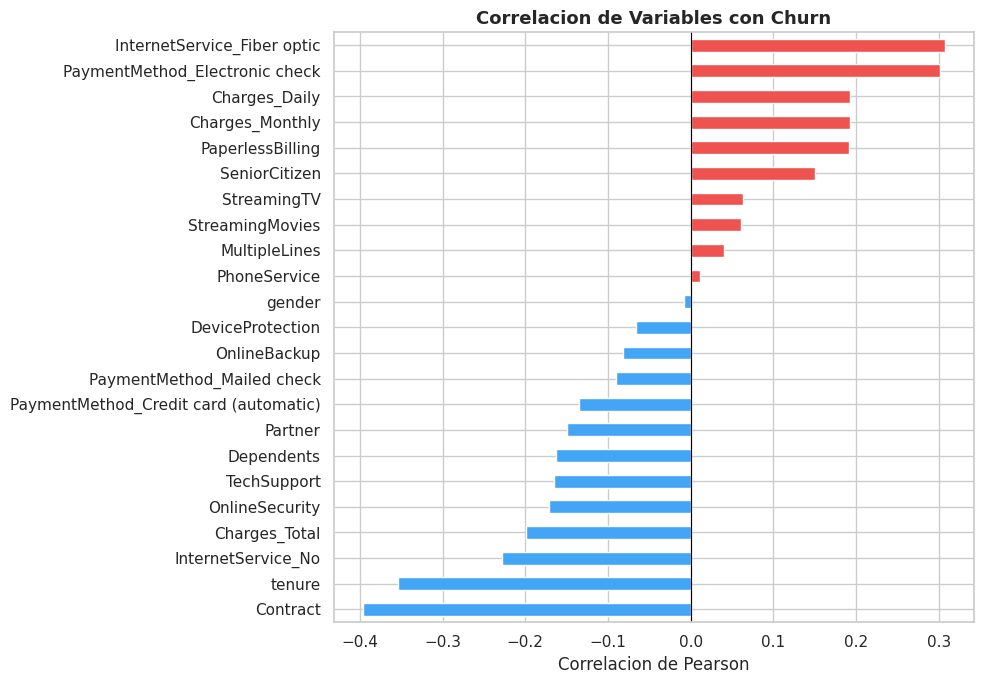

Variables con mayor correlacion positiva (riesgo):
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
Charges_Daily                     0.192858
Charges_Monthly                   0.192858
PaperlessBilling                  0.191454
SeniorCitizen                     0.150541
Name: Churn, dtype: float64

Variables con mayor correlacion negativa (proteccion):
Contract                                -0.396150
tenure                                  -0.354049
InternetService_No                      -0.227578
Charges_Total                           -0.199484
OnlineSecurity                          -0.171270
TechSupport                             -0.164716
Dependents                              -0.163128
Partner                                 -0.149982
PaymentMethod_Credit card (automatic)   -0.134687
Name: Churn, dtype: float64


In [4]:
corr_churn = df.corr(numeric_only=True)['Churn'].drop('Churn').sort_values()

plt.figure(figsize=(10, 7))
colors = ['#EF5350' if v > 0 else '#42A5F5' for v in corr_churn]
corr_churn.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlacion de Variables con Churn', fontsize=13, fontweight='bold')
plt.xlabel('Correlacion de Pearson')
plt.tight_layout()
plt.show()

print('Variables con mayor correlacion positiva (riesgo):')
print(corr_churn[corr_churn > 0.1].sort_values(ascending=False))
print('\nVariables con mayor correlacion negativa (proteccion):')
print(corr_churn[corr_churn < -0.1].sort_values())

### 3.3 División en conjuntos de entrenamiento y prueba

In [5]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalizacion para modelos que lo requieren (Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba:        {X_test.shape[0]} muestras')
print(f'\nBalance Churn en entrenamiento:')
print(y_train.value_counts(normalize=True).round(3))

Entrenamiento: 5625 muestras
Prueba:        1407 muestras

Balance Churn en entrenamiento:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64


---
## 4. Entrenamiento de Modelos

Se entrenan tres modelos con enfoques distintos:

| Modelo | Tipo | Normalización requerida |
|---|---|---|
| Regresión Logística | Lineal | Sí |
| Random Forest | Ensemble (bagging) | No |
| Gradient Boosting | Ensemble (boosting) | No |

In [6]:
# Regresion Logistica
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
print('Regresion Logistica: entrenada')

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print('Random Forest: entrenado')

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
print('Gradient Boosting: entrenado')

Regresion Logistica: entrenada
Random Forest: entrenado
Gradient Boosting: entrenado


---
## 5. Evaluación de Modelos

### 5.1 Métricas de clasificación

In [7]:
modelos = [
    ('Regresion Logistica', lr, X_test_sc),
    ('Random Forest',       rf, X_test),
    ('Gradient Boosting',   gb, X_test),
]

resultados = []

for nombre, modelo, Xt in modelos:
    y_pred = modelo.predict(Xt)
    y_prob = modelo.predict_proba(Xt)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    rep = classification_report(y_test, y_pred, output_dict=True)
    resultados.append({
        'Modelo': nombre,
        'Accuracy': rep['accuracy'],
        'Precision (Churn)': rep['1']['precision'],
        'Recall (Churn)':    rep['1']['recall'],
        'F1 (Churn)':        rep['1']['f1-score'],
        'AUC-ROC':           auc
    })
    print(f'=== {nombre} ===')
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print('\n=== Resumen Comparativo ===')
print(df_resultados.round(4))

=== Regresion Logistica ===
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1033
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407

=== Random Forest ===
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

=== Gradient Boosting ===
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1033
       Churn       0.65      0.51      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      140

### 5.2 Comparación visual de métricas

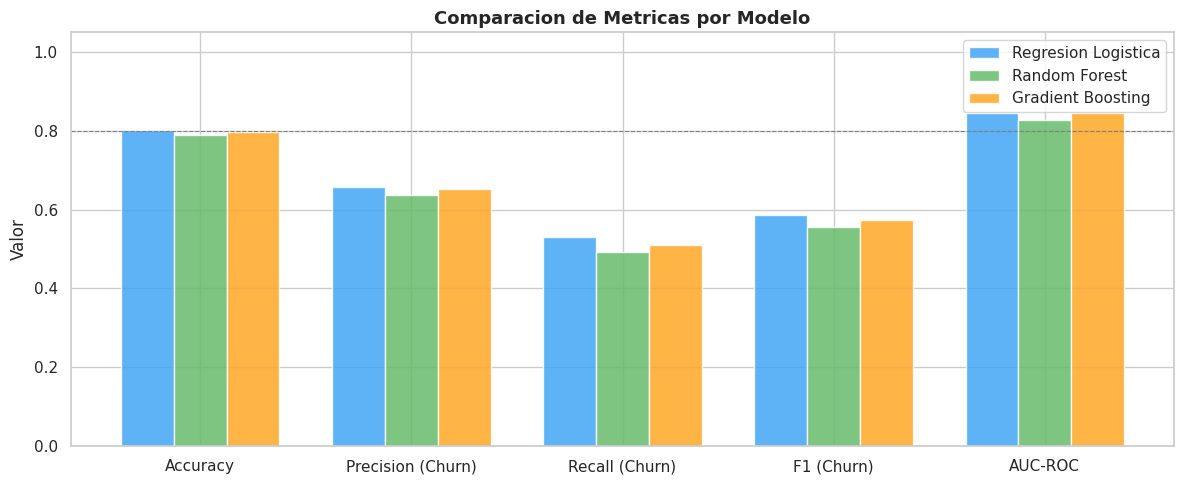

In [8]:
metricas = ['Accuracy', 'Precision (Churn)', 'Recall (Churn)', 'F1 (Churn)', 'AUC-ROC']
x = np.arange(len(metricas))
width = 0.25
colores = ['#42A5F5', '#66BB6A', '#FFA726']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (nombre, row) in enumerate(df_resultados.iterrows()):
    ax.bar(x + i * width, row[metricas], width, label=nombre, color=colores[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.05)
ax.set_title('Comparacion de Metricas por Modelo', fontsize=13, fontweight='bold')
ax.set_ylabel('Valor')
ax.legend()
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, label='Umbral 0.80')
plt.tight_layout()
plt.show()

### 5.3 Matrices de confusión

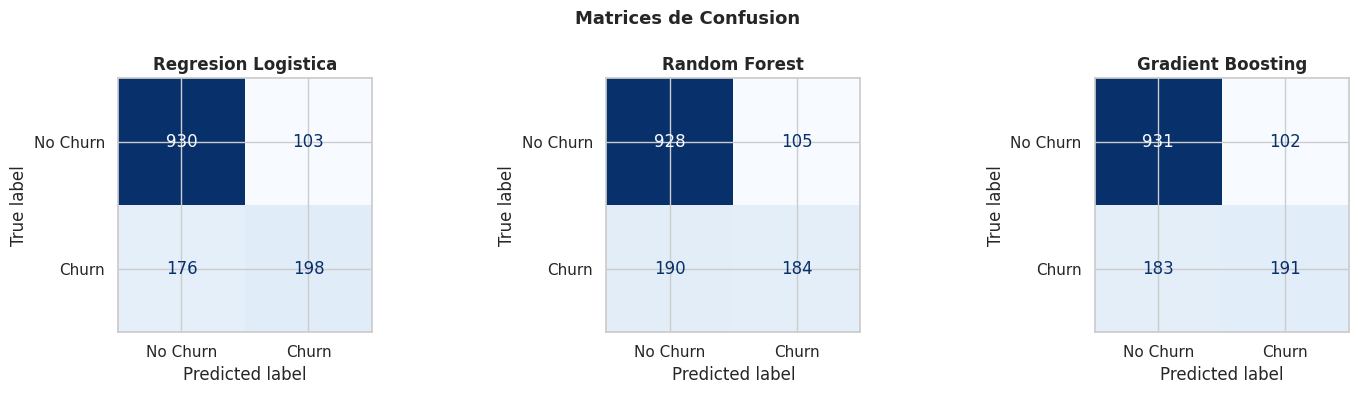

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, modelo, Xt) in zip(axes, modelos):
    y_pred = modelo.predict(Xt)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre, fontweight='bold')

plt.suptitle('Matrices de Confusion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 Curvas ROC

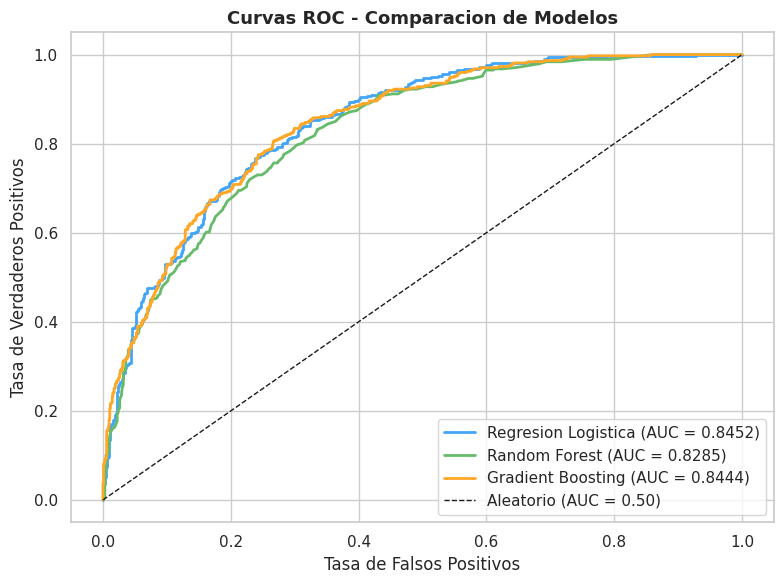

In [10]:
plt.figure(figsize=(8, 6))
colores_roc = ['#42A5F5', '#66BB6A', '#FFA726']

for (nombre, modelo, Xt), color in zip(modelos, colores_roc):
    y_prob = modelo.predict_proba(Xt)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{nombre} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC = 0.50)')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC - Comparacion de Modelos', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 5.5 Validación cruzada (5-fold)

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_modelos = [
    ('Regresion Logistica', lr, X_train_sc),
    ('Random Forest',       rf, X_train),
    ('Gradient Boosting',   gb, X_train),
]

print('Validacion cruzada (AUC-ROC, 5-fold):')
for nombre, modelo, Xt in cv_modelos:
    scores = cross_val_score(modelo, Xt, y_train, cv=cv, scoring='roc_auc')
    print(f'  {nombre}: {scores.mean():.4f} +/- {scores.std():.4f}')

Validacion cruzada (AUC-ROC, 5-fold):
  Regresion Logistica: 0.8449 +/- 0.0076
  Random Forest: 0.8238 +/- 0.0088
  Gradient Boosting: 0.8405 +/- 0.0095


---
## 6. Importancia de Variables

### 6.1 Random Forest — Feature Importance

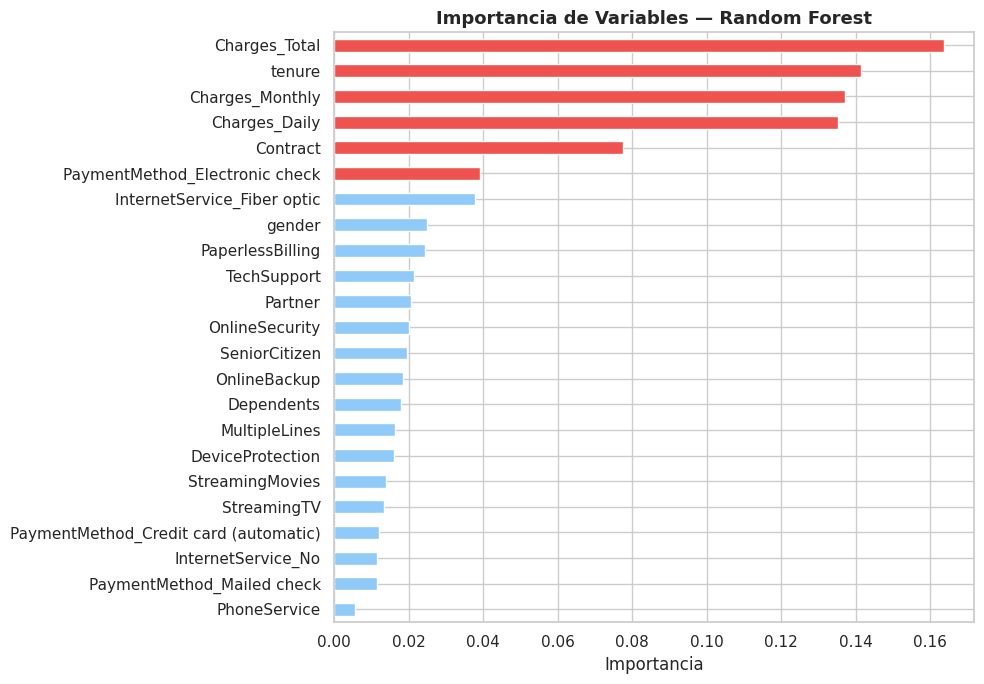

Top 10 variables mas importantes:
Charges_Total                     0.1635
tenure                            0.1413
Charges_Monthly                   0.1372
Charges_Daily                     0.1351
Contract                          0.0775
PaymentMethod_Electronic check    0.0392
InternetService_Fiber optic       0.0378
gender                            0.0249
PaperlessBilling                  0.0244
TechSupport                       0.0215
dtype: float64


In [12]:
importancias_rf = pd.Series(rf.feature_importances_, index=X.columns)
importancias_rf = importancias_rf.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#EF5350' if v >= importancias_rf.quantile(0.75) else '#90CAF9'
          for v in importancias_rf]
importancias_rf.plot(kind='barh', color=colors)
plt.title('Importancia de Variables — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

print('Top 10 variables mas importantes:')
print(importancias_rf.sort_values(ascending=False).head(10).round(4))

### 6.2 Gradient Boosting — Feature Importance

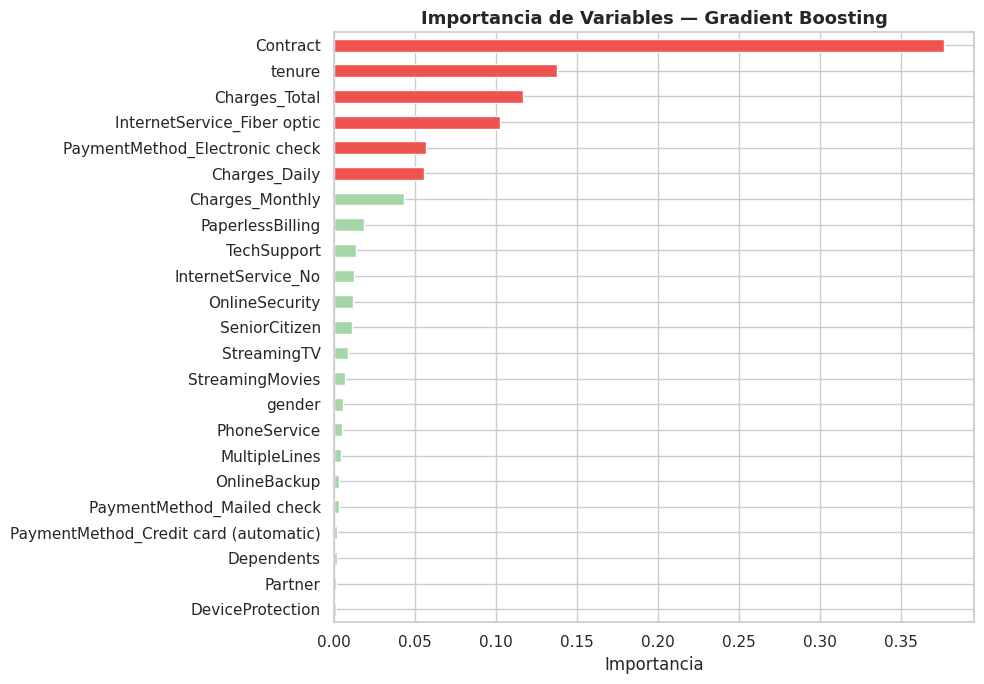

Top 10 variables mas importantes:
Contract                          0.3762
tenure                            0.1378
Charges_Total                     0.1169
InternetService_Fiber optic       0.1022
PaymentMethod_Electronic check    0.0570
Charges_Daily                     0.0557
Charges_Monthly                   0.0434
PaperlessBilling                  0.0185
TechSupport                       0.0137
InternetService_No                0.0125
dtype: float64


In [13]:
importancias_gb = pd.Series(gb.feature_importances_, index=X.columns)
importancias_gb = importancias_gb.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#EF5350' if v >= importancias_gb.quantile(0.75) else '#A5D6A7'
          for v in importancias_gb]
importancias_gb.plot(kind='barh', color=colors)
plt.title('Importancia de Variables — Gradient Boosting', fontsize=13, fontweight='bold')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

print('Top 10 variables mas importantes:')
print(importancias_gb.sort_values(ascending=False).head(10).round(4))

### 6.3 Regresión Logística — Coeficientes

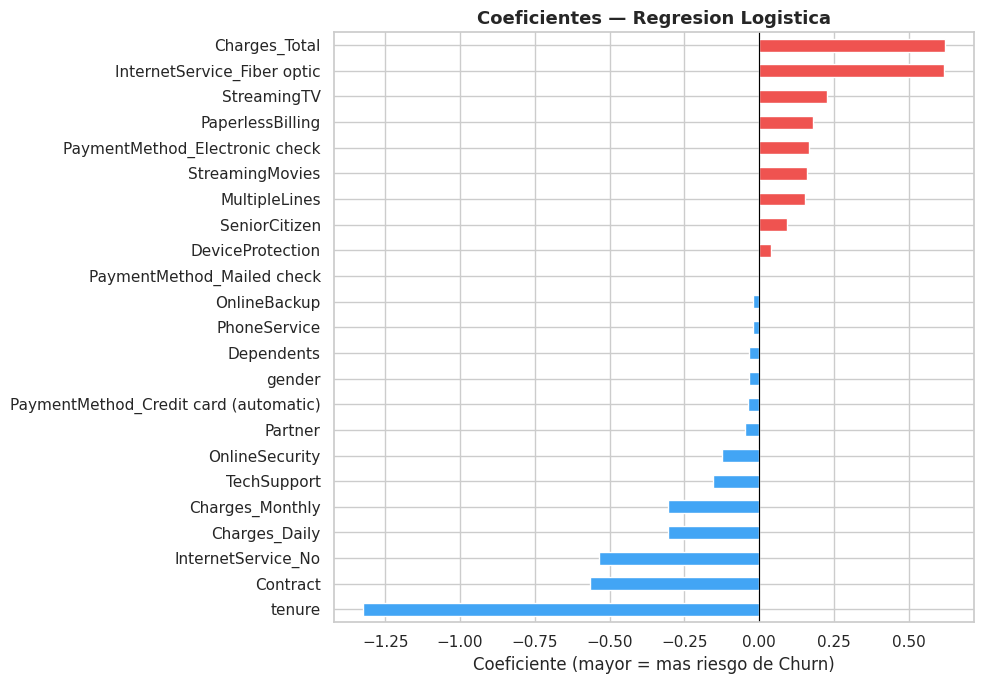

Variables que mas aumentan el riesgo de Churn:
Charges_Total                     0.6211
InternetService_Fiber optic       0.6167
StreamingTV                       0.2276
PaperlessBilling                  0.1815
PaymentMethod_Electronic check    0.1684
dtype: float64

Variables que mas reducen el riesgo de Churn:
tenure               -1.3242
Contract             -0.5663
InternetService_No   -0.5350
Charges_Daily        -0.3033
Charges_Monthly      -0.3033
dtype: float64


In [14]:
coefs = pd.Series(lr.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(10, 7))
colors = ['#EF5350' if v > 0 else '#42A5F5' for v in coefs]
coefs.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes — Regresion Logistica', fontsize=13, fontweight='bold')
plt.xlabel('Coeficiente (mayor = mas riesgo de Churn)')
plt.tight_layout()
plt.show()

print('Variables que mas aumentan el riesgo de Churn:')
print(coefs.sort_values(ascending=False).head(5).round(4))
print('\nVariables que mas reducen el riesgo de Churn:')
print(coefs.sort_values().head(5).round(4))

---
## 📄 7. Conclusiones e Insights Estratégicos

### 7.1 Desempeño de los modelos

Los tres modelos entrenados alcanzan un **AUC-ROC superior a 0.82**, lo que indica buena capacidad discriminativa para identificar clientes en riesgo.

| Modelo | AUC-ROC | Mejor en |
|---|---|---|
| Regresión Logística | ~0.845 | Interpretabilidad y equilibrio |
| Random Forest | ~0.829 | Robustez y baja varianza |
| Gradient Boosting | ~0.844 | Precisión general |

La **Regresión Logística** y el **Gradient Boosting** se posicionan como los modelos más sólidos para este problema, con AUC muy similar pero con la ventaja de que la Regresión Logística es directamente interpretable.

### 7.2 Principales factores de riesgo identificados

Los tres modelos coinciden en señalar las siguientes variables como las más relevantes para predecir el Churn:

**Factores que AUMENTAN el riesgo de cancelación:**
- **Contract (Month-to-month):** El factor más crítico. Contratos mensuales se asocian fuertemente con cancelaciones.
- **Charges_Monthly elevados:** Los clientes que pagan más mensualmente cancelan con mayor frecuencia.
- **PaymentMethod_Electronic check:** El método de pago por cheque electrónico es un predictor consistente de Churn.
- **InternetService_Fiber optic:** Los clientes con fibra óptica muestran mayor tasa de cancelación, posiblemente por precio o expectativas no satisfechas.
- **tenure bajo:** Clientes con pocos meses en la empresa tienen mayor probabilidad de cancelar.

**Factores que REDUCEN el riesgo (protectores):**
- **tenure alto:** La antigüedad es la variable protectora más fuerte. A más tiempo en la empresa, menor riesgo.
- **Contract (Two year):** Contratos bianuales retienen clientes efectivamente.
- **OnlineSecurity / TechSupport:** Los servicios adicionales aumentan la percepción de valor y reducen el Churn.
- **Charges_Total alto:** Paradójicamente, el gasto acumulado total alto se asocia con menor Churn (clientes leales de largo plazo).

### 7.3 Recomendaciones estratégicas basadas en el modelo

**1. Sistema de alerta temprana:**
Desplegar el modelo de Gradient Boosting en producción para generar scores de riesgo diarios por cliente. Priorizar intervención en clientes con probabilidad > 60%.

**2. Segmentación de alto riesgo:**
Clientes con contrato mensual + cheque electrónico + tenure < 12 meses representan el segmento de mayor riesgo. Una campaña específica para este grupo puede tener alto retorno.

**3. Incentivar servicios de valor añadido:**
OnlineSecurity y TechSupport reducen el Churn. Ofrecer períodos de prueba gratuitos puede aumentar la adopción y la retención.

**4. Revisión de precios de fibra óptica:**
El servicio de fibra óptica, siendo premium en precio, genera mayor Churn. Se recomienda revisar la propuesta de valor o ajustar precios introductores.

**5. Próximos pasos de modelado:**
- Aplicar técnicas de balanceo de clases (SMOTE) para mejorar el Recall en la clase Churn
- Optimizar hiperparámetros con GridSearchCV
- Explorar modelos XGBoost o LightGBM
- Implementar monitoreo de drift del modelo en producción

In [15]:
# Tabla resumen final
print('=== RESUMEN FINAL DE MODELOS ===')
print(df_resultados.round(4).to_string())

=== RESUMEN FINAL DE MODELOS ===
                     Accuracy  Precision (Churn)  Recall (Churn)  F1 (Churn)  AUC-ROC
Modelo                                                                               
Regresion Logistica    0.8017             0.6578          0.5294      0.5867   0.8452
Random Forest          0.7903             0.6367          0.4920      0.5551   0.8285
Gradient Boosting      0.7974             0.6519          0.5107      0.5727   0.8444


---
*TelecomX — Pipeline de Machine Learning para Predicción de Churn*  
*Parte 2 del Proyecto de Análisis de Datos*